In [1]:
%%capture
%run script_nettoyage.ipynb

In [2]:
# Importation des librairies
import pandas as pd


# Importation des données externes
from data import pop_2010


# Importation des fonctions personnalisées
from fonctions import (
    tracer_comparaison_frequentation,
    beau_tableau,
    generer_carte_musees,
    carto_frequentation_region,
    carto_beaux_arts_themes
)

## 1. Analyse de la fréquentation des musées entre les années

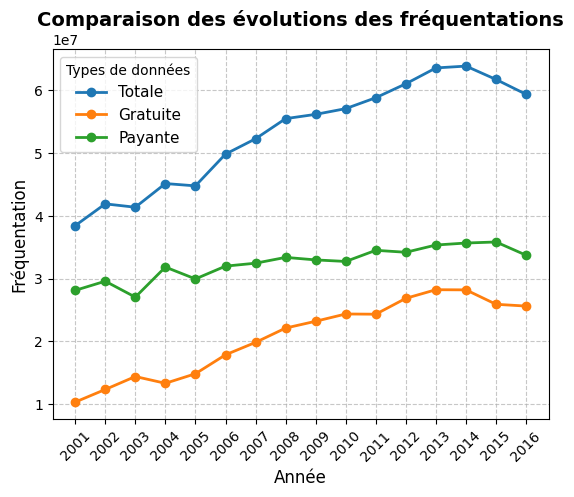

In [3]:
mes_donnees = {
    "Totale": df_freq_totale,
    "Gratuite": df_freq_gratuite,
    "Payante": df_freq_payante    
}

tracer_comparaison_frequentation(
    mes_donnees, 
    an='annee',           
    freq='freq_net'    
)

La fréquentation totale semble avoir augmenté au fil des ans. La fréquentation de musées de manière payante est plus forte que la fréquentation gratuite.

## 2. Analyse de la fréquentation des musées par région

Dans un premier temps, nous souhaitons étudier le nombres de musées fermés par régions. Fermer un musée pourrait agir comme un frein à la fréquentation.

In [4]:
# Garde toutes les lignes où le Statut est 'Fermé'
df_reg = (
    df_freq_totale[df_freq_totale['Statut'] == 'Fermé']
    .copy()
    )
df_reg_2014 = df_reg[df_reg['annee'] == '2014']


# Tableau croisé par région
# Remplacer 'region' par le nom exact de votre colonne géographique
tableau_statut_region = (
    pd
    .crosstab(df_reg_2014['NOMREG'], df_reg_2014['Statut'])
    )


# On trie par ordre croissant
tableau_statut_region_trié = (
    tableau_statut_region
    .sort_values(by='Fermé', ascending=True)
    )


# Transformation en DataFrame
tableau_statut_region_trié = tableau_statut_region_trié.reset_index()
tableau_statut_region_trié.columns = ['Région', 'Nombre de musées fermés']


# Affichage
beau_tableau(
    tableau_statut_region_trié,
    "Répartition des musées fermés par régions en 2014"
    )


GT(_tbl_data=                        Région  Nombre de musées fermés
0                     BRETAGNE                        1
1                   MARTINIQUE                        1
2                   GUADELOUPE                        2
3                        CORSE                        2
4             PAYS DE LA LOIRE                        7
5                    GRAND EST                        9
6                    NORMANDIE                       10
7   PROVENCE-ALPES-CÔTE D'AZUR                       10
8              HAUTS-DE-France                       12
9          CENTRE-VAL DE LOIRE                       14
10     BOURGOGNE-FRANCHE-COMTE                       15
11        AUVERGNE-RHÔNE-ALPES                       15
12                   OCCITANIE                       15
13               ÎLE-DE-France                       16
14          NOUVELLE-AQUITAINE                       22, _body=<great_tables._gt_data.Body object at 0x7fdef041f620>, _boxhead=Boxhead([ColInfo(var='Région', type=<ColInfoTypeEnum.default: 1>, column_label='Région', column_align='center', column_width=None), ColInfo(var='Nombre de musées fermés', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de musées fermés', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdef041f230>, _spanners=Spanners([]), _heading=Heading(title=Html(text='<b>Répartition des musées fermés par régions en 2014</b>'), subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdef041fa10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fdef07f0b90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fdef041fb60>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fdef041f8c0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='14px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='3px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#444444'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boo

En 2014, en Nouvelle-Aquitaine, plus de musées étaient fermés.

Ensuite, nous souhaitons analyser le nombre de musées par région. En effet, cela constitue un point d'analyse important : on pourrait penser que plus il y a de musées, plus il y aura de visiteurs. Pour cela, nous allons utiliser la fonction generer_carte_musees, qui permet de générer une carte représentant la répartition du nombre de région pour une année donnée.

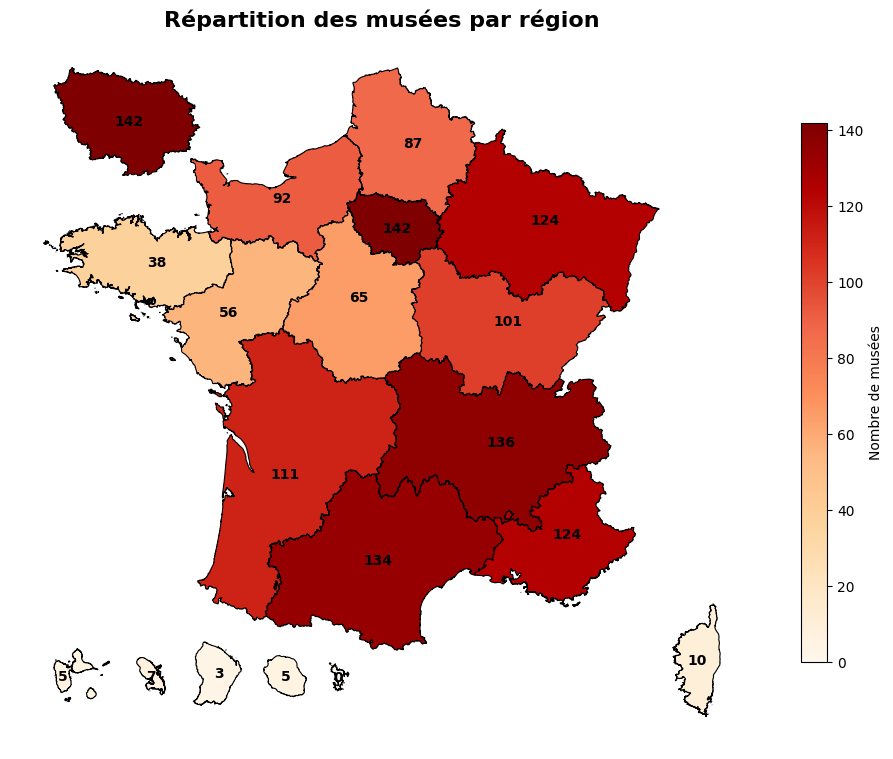

In [5]:
generer_carte_musees(df_freq_totale, '2014')

Nous remarquons une disparités dans le nombre de musées par région : la Bretagne et les région d'Outre-mer en possèdent moins, l'Île-de-France et les régions du sud en possèdent plus. Cela peut avoir une influence sur la fréquentation des musées dans les régions.

Nous souhaitons à présent représenter sur une carte de la France métropolitaine la fréquentation des musées par région. Cependant, nous voulons également représenter la fréquentation par rapport au nombre d'habitants dans la région. Pour cela nous utilisons une table présentant le nombre d'habitants par région en 2010 (fichier data.py). Nous faisons ensuite une jointure de cette table avec notre table fréquentation_totale. Le fait de prendre comme 2010 comme référence pour toutes les années de notre base de données n'est pas précis; l'objectif n'est pas d'être précis mais de montrer les tendances. Nous créons la colonne freq_pour_1000_hab représentant la fréquentation du musée, une année donnée pour 1 000 habitants.

In [6]:
df_freq_totale = (
    df_freq_totale
    .merge(pop_2010, on="NOMREG", how="left")
    )
df_freq_totale["freq_pour_1000_hab"] = (
    pd.to_numeric(df_freq_totale["freq_net"], errors="coerce")
    / df_freq_totale["population_2010"] * 1000
)
#df_freq_totale

La fonction carto_frequentation_region permet de représenter sur une carte de la France métropolitaine la fréquentation par région une année donnée par quartiles. L'argument col_freq permet de choisir entre représenter la fréquentation ou la fréquentation pour 1 000 habitants.

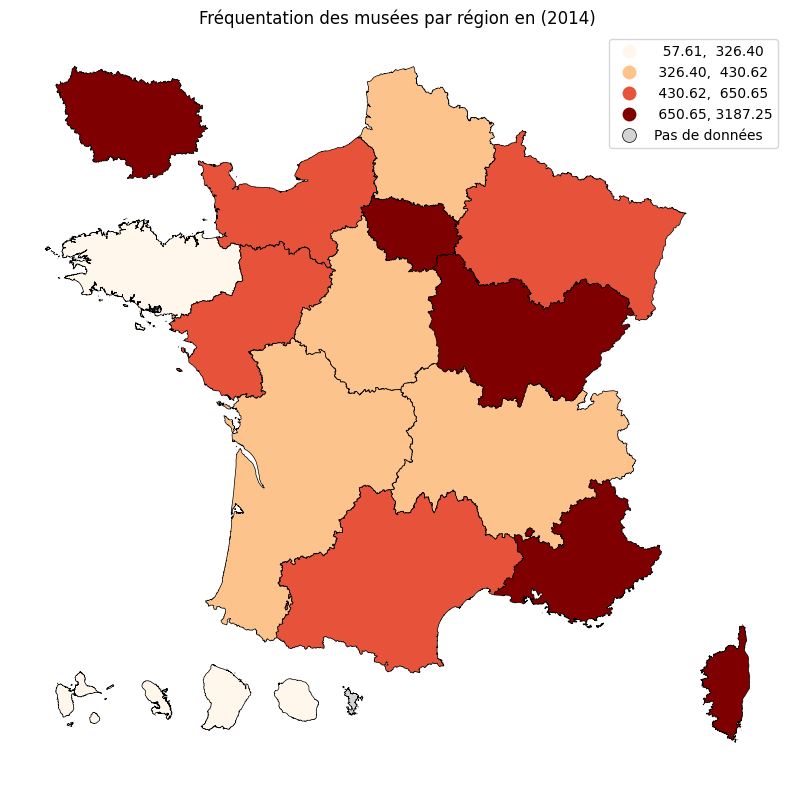

In [7]:
carte_2022 = (
    carto_frequentation_region(
        df_freq_totale, "2014", 
        col_freq="freq_pour_1000_hab")
        )

Au moins une région dépasse les 1 000 visiteurs pour 1 000 habitants. Qui dépasse ce seuil et en quelles années ?

In [8]:
freq_region_annee = (
    df_freq_totale
    .groupby(["annee", "NOMREG"], as_index=False)["freq_pour_1000_hab"]
    .sum()
)

freq_region_annee.loc[
    freq_region_annee["freq_pour_1000_hab"] > 1000,
    ["annee", "NOMREG", "freq_pour_1000_hab"]
].sort_values(["NOMREG", "annee"])

,annee,NOMREG,freq_pour_1000_hab
17,2001,ÎLE-DE-France,1672.452286
35,2002,ÎLE-DE-France,1808.144484
53,2003,ÎLE-DE-France,1805.578949
71,2004,ÎLE-DE-France,2028.775180
89,2005,ÎLE-DE-France,2117.515654
107,2006,ÎLE-DE-France,2517.444419
125,2007,ÎLE-DE-France,2635.561368
143,2008,ÎLE-DE-France,2805.628838
161,2009,ÎLE-DE-France,2814.197818
179,2010,ÎLE-DE-France,2838.559289


La région Ile-De-France dépasse ce seuil tous les ans. Cela s'explique par le tourisme très important que connaît cette région.

Par ailleurs, nous remarquons que le nombre de musées ne semble que peu influencer la fréquentation. En effet, la région Auvergne-Rhône-Alpes présente une fréquentation pour 1000 habitants faible, alors qu'elle abrite un grand nombre de musées (136 musées, ce qui est le deuxième plus haut score). En outre, nous remarquons, que le nombre de musées fermés ne semble pas vraiment influencer la fréquentation.

Ce qui ressort de cette analyse est que l'attractivité touristique génère de plus grandes fréquentations de musées. Les régions comme la Corse, Paris ou encore PACA, montrent une forte fréquentation pour 1000 habitants. La Corse en particulier, va dans ce sens, puisqu'elle n'a que très peu de musées mais répertorie l'un des plus grands nombres de fréquentation pour 1000 habitants.

## 3. Analyse des thématiques qui peuvent influencer la fréquentation de musées

Commençons par étudier le classement des thèmes : du plus abordé au moins abordé.

In [9]:
# Liste de tes thèmes 
themes = list(colonnes_binaires.columns)


# Liste de colonnes à garder
colonnes_a_garder = ["NOMREG", "IDMuseofile", "annee"] + themes


# On ne garde que certaines colonnes pour faire l'étude
df_musees_themes = (
    df_freq_totale[colonnes_a_garder]
    .copy()
    )


# On crée un DataFrame avec une seule ligne par musée
# On garde l'ID et les thèmes pour le calcul
df_unique_musees = (
    df_musees_themes
    .drop_duplicates(subset=['IDMuseofile']))


# On sélectionne uniquement les colonnes de thèmes
df_themes_uniques = df_unique_musees[themes]


# On fait la somme et on trie (cela crée une Series)
classement_them_final = (
    df_themes_uniques
    .sum()
    .sort_values(ascending=False)
    )


# Transformation en DataFrame et renommage des colonnes
classement_them_final = (
    classement_them_final
    .reset_index()
    )
classement_them_final.columns = ['Thème', 'Nombre de musées']


# Affichage des 15 premiers thèmes
beau_tableau(
    classement_them_final.head(15), 
    "Classement des 15 premiers thèmes abordés"
    )


GT(_tbl_data=                          Thème  Nombre de musées
0                    Beaux_arts               533
1                   Archeologie               514
2               Arts_decoratifs               390
3        Technique et industrie               274
4   Art moderne et contemporain               229
5         Sciences de la nature               202
6                          Asie                89
7                       Oceanie                66
8                      Amerique                62
9                   Litterature                39
10              Arts de l'Islam                32
11       Sciences fondamentales                26
12                    Militaria                15
13                     Egyptien                10
14       Mémoire de l'esclavage                 6, _body=<great_tables._gt_data.Body object at 0x7fde431c5220>, _boxhead=Boxhead([ColInfo(var='Thème', type=<ColInfoTypeEnum.default: 1>, column_label='Thème', column_align='center', column_width=None), ColInfo(var='Nombre de musées', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de musées', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fdef0abe710>, _spanners=Spanners([]), _heading=Heading(title=Html(text='<b>Classement des 15 premiers thèmes abordés</b>'), subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fdef0abdbd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fde431c5350>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fde4357e850>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fde4357ec10>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='14px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='3px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#444444'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), tab

La thématique "Beaux-Arts" est très largement supérieure avec 533 musées qui possèdent une collection de Beaux-Arts. L'archéologie se distingue aussi. Les thèmes supérieurs sont : Beaux-arts Archéologie, Arts décoratifs, Technique et industrie, Art moderne et contemporain et, enfin, Sciences de la nature. Les autres thèmes sont beaucoup moins représentés.

À présent, nous aimerions étudier la répartition des musées des Beaux-Arts par région.

In [10]:
# On garde un seul musée par ligne
df_unique = (
    df_musees_themes
    .drop_duplicates(subset=['IDMuseofile'])
    .copy())


# On fait la somme du thème par région
stats_region = (
    df_unique
    .groupby("NOMREG", as_index=False)["Beaux_arts"]
    .sum())


# On trie par la colonne "Beaux_arts" en ordre croissant
stat_classees = (
    stats_region
    .sort_values(by="Beaux_arts", ascending=False)
    .head(5)
    )
beau_tableau(
    stat_classees, 
    "5 premières régions proposant une section Beaux-Arts"
    )

GT(_tbl_data=                        NOMREG  Beaux_arts
17               ÎLE-DE-France          67
1      BOURGOGNE-FRANCHE-COMTE          56
15  PROVENCE-ALPES-CÔTE D'AZUR          52
8              HAUTS-DE-France          50
12          NOUVELLE-AQUITAINE          50, _body=<great_tables._gt_data.Body object at 0x7fde431dd6a0>, _boxhead=Boxhead([ColInfo(var='NOMREG', type=<ColInfoTypeEnum.default: 1>, column_label='NOMREG', column_align='center', column_width=None), ColInfo(var='Beaux_arts', type=<ColInfoTypeEnum.default: 1>, column_label='Beaux_arts', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fde4357efd0>, _spanners=Spanners([]), _heading=Heading(title=Html(text='<b>5 premières régions proposant une section Beaux-Arts</b>'), subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fde431c5810>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fde431f9a30>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fde4357f250>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fde4357f890>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='14px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='3px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#444444'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type

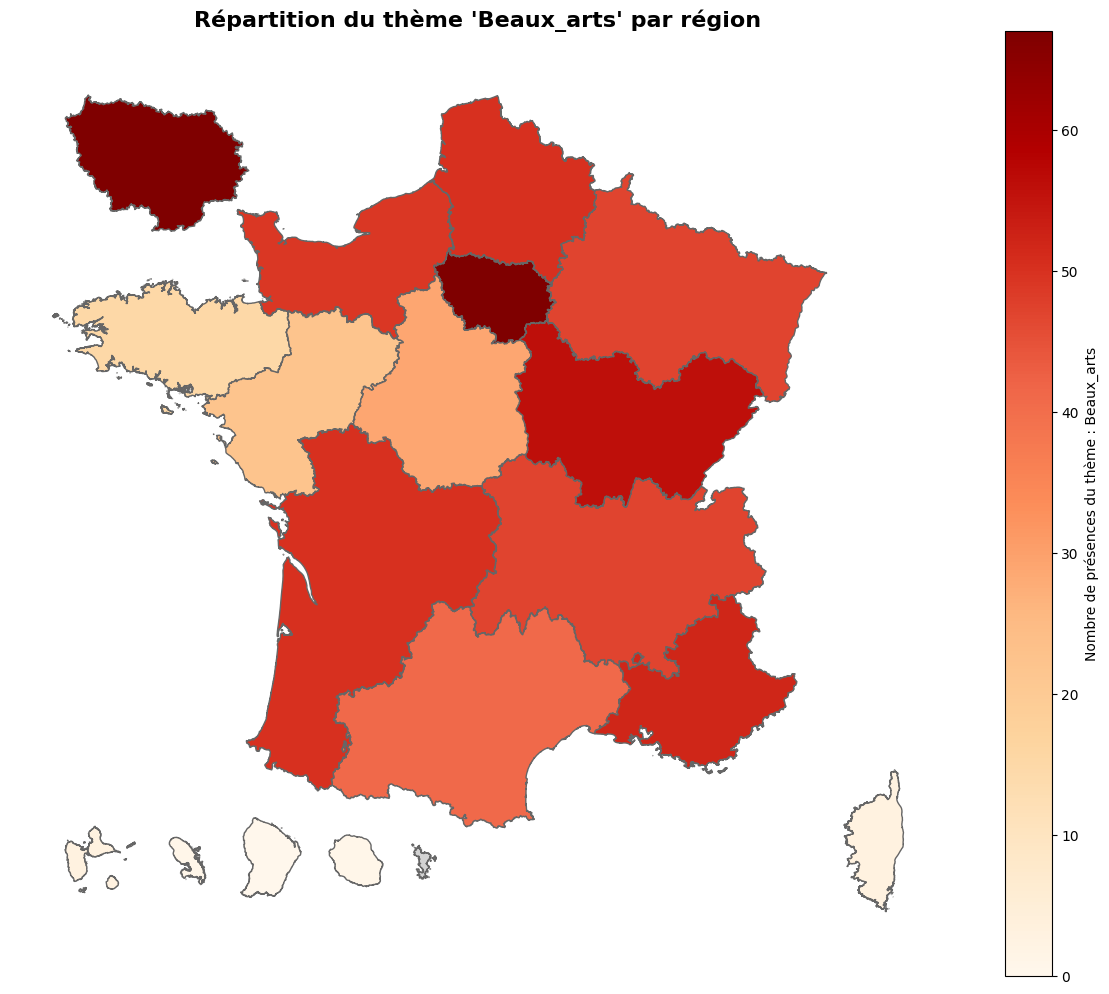

In [11]:
# Pour le thèmes des Beaux-arts
carto_beaux_arts_themes(df_musees_themes, "Beaux_arts")

L'Île-de-France aborde le plus la thématique 'Beaux-arts', mais ce résultat est à relativiser : la région possède aussi plus de musées. La région Hauts-De-France se distingue par son nombre de fois abordées comparé à son nombre de musées : 50 musées qui aborde le thème pour 85 musées.

Nous pouvons maintenant étudier le nombre thèmes abordés par région.

In [12]:
# On filtre les données pour ne garder que l'année 2014
df_2014 = df_musees_themes[df_musees_themes["annee"] == '2014']


# On garde un seul musée par ligne pour éviter les doublons
df_unique_2014 = (
    df_2014
    .drop_duplicates(subset=['IDMuseofile'])
    )


# On fait la somme de chaque thème, par région
somme_themes_region = (
    df_unique_2014
    .groupby("NOMREG")[themes]
    .sum()
    )


# On compte le nombre de thèmes abordés par région
nombre_themes_par_region = (
    (somme_themes_region > 0)
    .sum(axis=1)
    )


# On trie le résultat pour voir la région avec le plus de thèmes en premier
classement_regions = (
    nombre_themes_par_region
    .sort_values(ascending=False)
    )


# Affichage du résultat
classement_regions


# Transformation en DataFrame
df_regions = (
    classement_regions
    .reset_index()
    )
df_regions.columns = ['Région', 'Nombre de thèmes']


# Affichage des 10 premiers
beau_tableau(
    df_regions.head(10), 
    "Classement des 10 premières régions selon le nombre de thèmes"
    )

GT(_tbl_data=                       Région  Nombre de thèmes
0        AUVERGNE-RHÔNE-ALPES                20
1                   GRAND EST                18
2                   NORMANDIE                18
3            PAYS DE LA LOIRE                17
4          NOUVELLE-AQUITAINE                16
5                    BRETAGNE                16
6     BOURGOGNE-FRANCHE-COMTE                15
7                   OCCITANIE                15
8  PROVENCE-ALPES-CÔTE D'AZUR                15
9               ÎLE-DE-France                15, _body=<great_tables._gt_data.Body object at 0x7fdef0476d50>, _boxhead=Boxhead([ColInfo(var='Région', type=<ColInfoTypeEnum.default: 1>, column_label='Région', column_align='center', column_width=None), ColInfo(var='Nombre de thèmes', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre de thèmes', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fde431c62c0>, _spanners=Spanners([]), _heading=Heading(title=Html(text='<b>Classement des 10 premières régions selon le nombre de thèmes</b>'), subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fde431ddf20>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fde431de140>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fde431c6520>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fde431c69e0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='14px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='3px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#444444'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table

On remarque que le nombre de thèmes ne semble pas corrélé avec la fréquentation de musées ni au nommbre de musées présents dans la région. En effet, une fois encore, la région Auvergne-Rhône-Alpes répertorie le plus grand nombre de thématiques, et pourtant, enregistre une faible fréquentation. De plus, la Bretagne aborde 16 thématiques mais ne possède que très peu de musées.

## Conclusion de partie

Il ressort que le facteur principal qui influence la fréquentation est le tourisme. En effet, nous avons remarqué que les régions montrant une plus haute fréquentation de musées sont aussi les régions touristiques. Nous aurions pu élargir l'analyse au champ du tourisme pour confirmer l'hypothèse.